<a href="https://colab.research.google.com/github/tasninkhanlamha/SkillMorph/blob/main/ML_Full_source_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



> Import Required Libraries



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from google.colab import drive
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier, ExtraTreesClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

print("Libraries loaded successfully")

Libraries loaded successfully


Load the Dataset

In [ ]:
drive.mount('/content/drive')
df = df = pd.read_csv("/content/drive/MyDrive/Skill-Morph/Android_Ransomeware.csv")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Unnamed: 0,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,172.217.2.174-10.42.0.211-443-51023-6,10.42.0.211,51023,172.217.2.174,443,6,16/06/2017 03:55:47,151054,6,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,1,172.217.2.174-10.42.0.211-443-51023-6,10.42.0.211,51023,172.217.2.174,443,6,16/06/2017 03:55:47,349,2,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,2,172.217.12.174-10.42.0.211-443-34259-6,10.42.0.211,34259,172.217.12.174,443,6,16/06/2017 03:55:52,119,2,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,3,172.217.10.74-10.42.0.211-443-55509-6,10.42.0.211,55509,172.217.10.74,443,6,16/06/2017 03:55:53,37055,1,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
4,4,172.217.2.174-10.42.0.211-443-44852-6,10.42.0.211,44852,172.217.2.174,443,6,16/06/2017 03:55:58,178727,6,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


Dataset Structure and Basic Information

In [ ]:
print("--- DATASET SHAPE ---")
print(df.shape)
print("\n")

print("--- COLUMN DETAILS ---")
print(df.columns)
print("\n")

print("--- DATASET INFO ---")
df.info()
print("--- SUMMARY STATISTICS ---")
df.describe()
print("--- MISSING VALUES COUNT ---")
df.isnull().sum()


--- DATASET SHAPE ---
(392034, 86)


--- COLUMN DETAILS ---
Index(['Unnamed: 0', 'Flow ID', ' Source IP', ' Source Port',
       ' Destination IP', ' Destination Port', ' Protocol', ' Timestamp',
       ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets',
       'Total Length of Fwd Packets', ' Total Length of Bwd Packets',
       ' Fwd Packet Length Max', ' Fwd Packet Length Min',
       ' Fwd Packet Length Mean', ' Fwd Packet Length Std',
       'Bwd Packet Length Max', ' Bwd Packet Length Min',
       ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s',
       ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max',
       ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std',
       ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean',
       ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags',
       ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags',
       ' Fwd Header Length', ' Bwd Header Length'

,0
Unnamed: 0,0
Flow ID,0
Source IP,0
Source Port,0
Destination IP,0
...,...
Idle Mean,0
Idle Std,0
Idle Max,0
Idle Min,0


Distribution of Application Labels

In [ ]:
df['Label'].value_counts()

,count
Label,
SVpeng,54161
PornDroid,46082
Koler,44555
Benign,43091
RansomBO,39859
Charger,39551
Simplocker,36340
WannaLocker,32701
Jisut,25672


Ransomware vs Benign Distribution

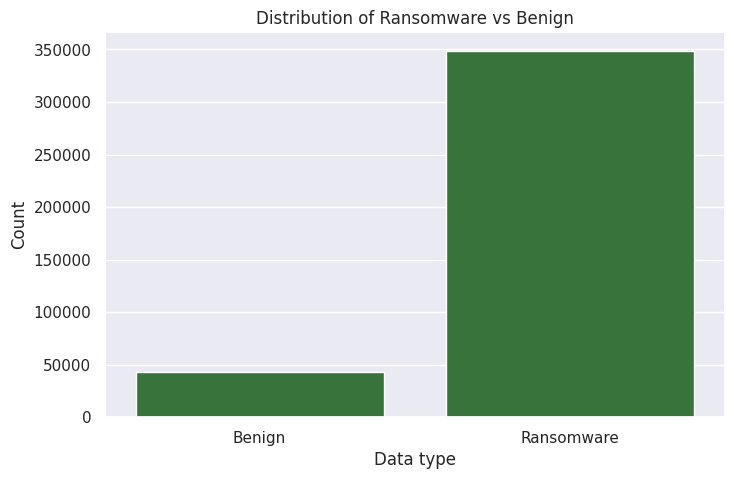

In [ ]:
sns.set_theme(style="darkgrid")

plt.figure(figsize=(8, 5))

overview_labels = df['Label'].apply(lambda x: 'Benign' if x == 'Benign' else 'Ransomware')

sns.countplot(x=overview_labels,color="#2E7D32")

plt.title("Distribution of Ransomware vs Benign")
plt.xlabel('Data type')
plt.ylabel('Count')

plt.show()

Distribution

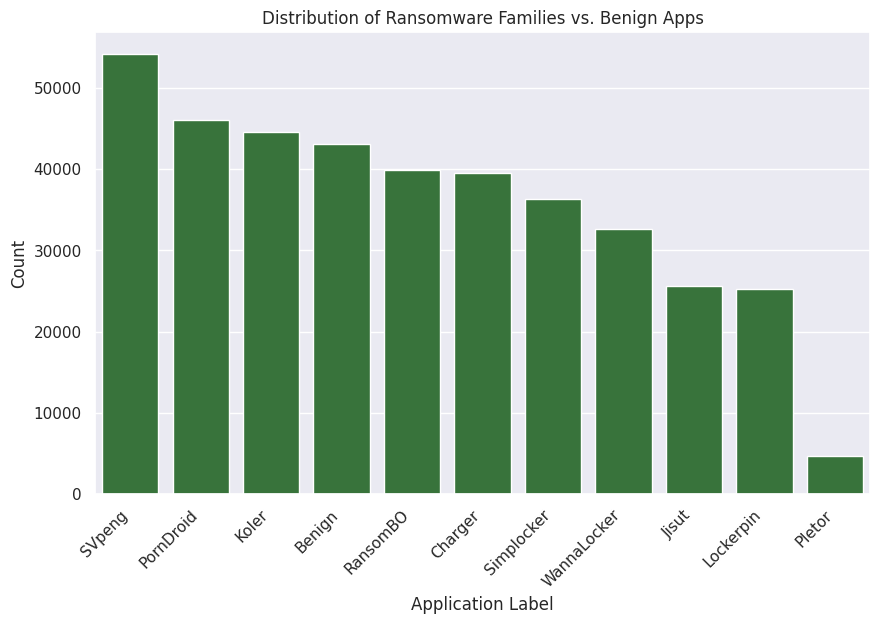

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(x='Label',color="#2E7D32", data=df, order=df['Label'].value_counts().index)

plt.title('Distribution of Ransomware Families vs. Benign Apps')
plt.xlabel('Application Label')
plt.ylabel('Count')

plt.xticks(rotation=45, ha='right')

plt.show()

Feature Correlation Analysis

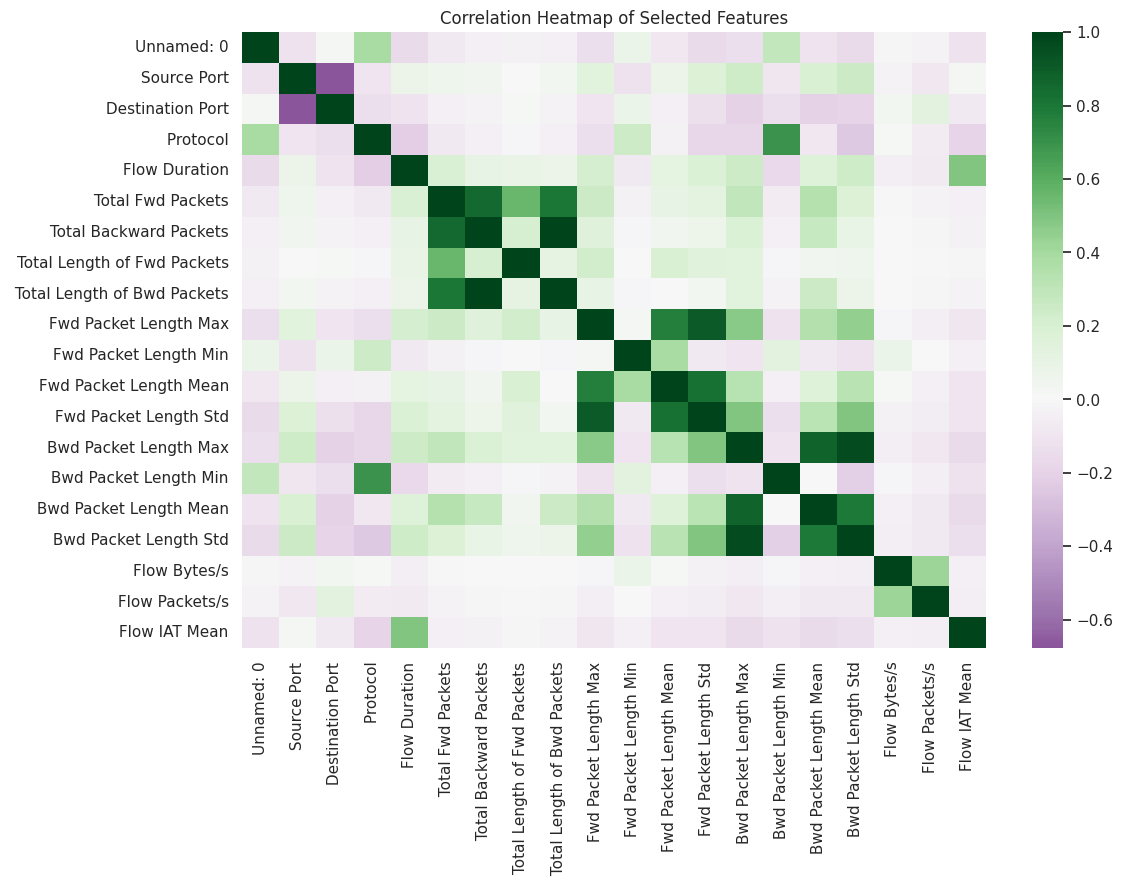

In [ ]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Take first 20 numerical columns for visualization
subset_features = numeric_df.iloc[:, :20]

# Compute correlation matrix
correlation_matrix = subset_features.corr()

plt.figure(figsize=(12,8))

#sns.heatmap(correlation_matrix, cmap="coolwarm", annot=False)
sns.heatmap(correlation_matrix, cmap="PRGn", center=0, annot=False)

plt.title("Correlation Heatmap of Selected Features")

plt.show()

Flow Duration Distribution

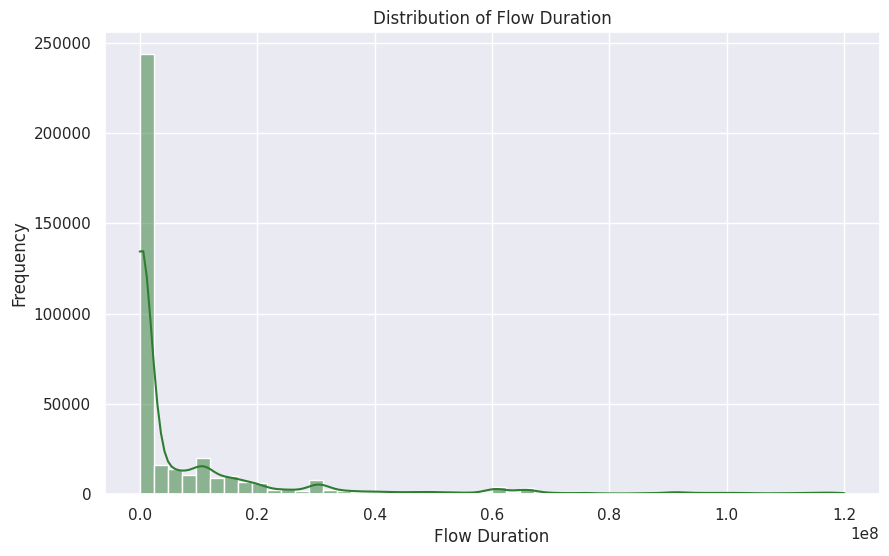

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(df[' Flow Duration'], bins=50, kde=True,color="#2E7D32")

plt.title("Distribution of Flow Duration")
plt.xlabel("Flow Duration")
plt.ylabel("Frequency")

plt.show()

 Packet Length Analysis

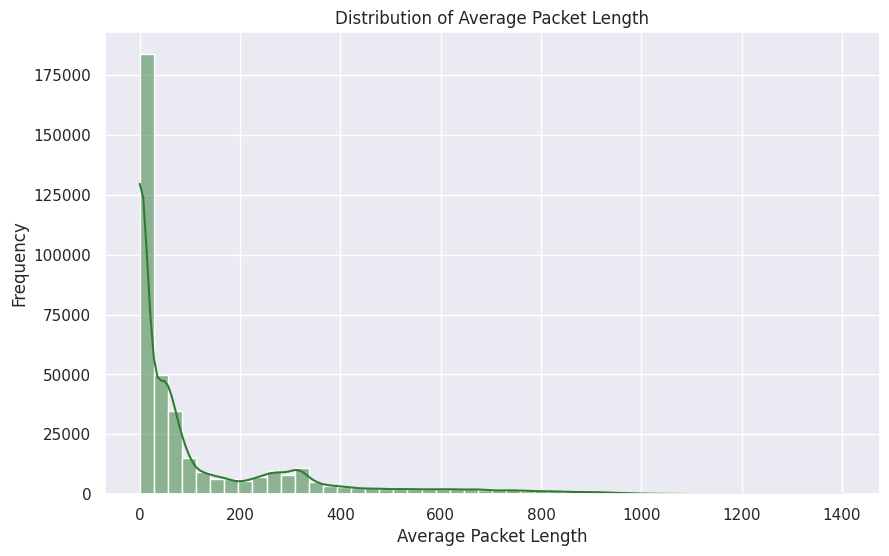

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(df[' Packet Length Mean'], bins=50, kde=True,color="#2E7D32")

plt.title("Distribution of Average Packet Length")
plt.xlabel("Average Packet Length")
plt.ylabel("Frequency")

plt.show()

Network Protocol Distribution

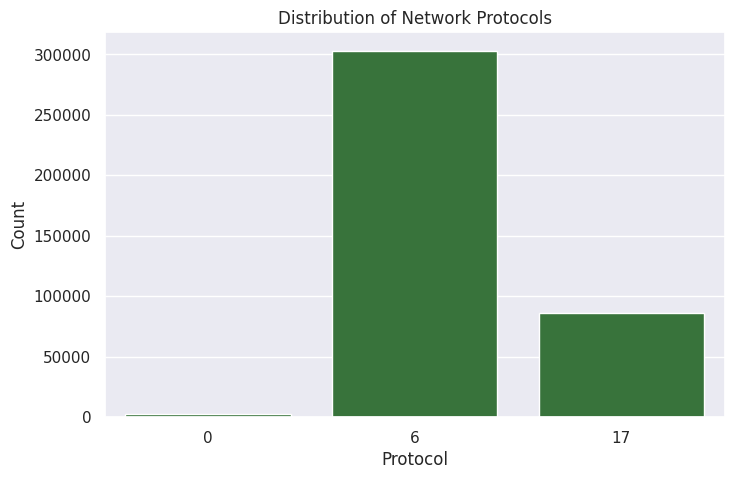

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x=' Protocol', data=df,color="#2E7D32")

plt.title("Distribution of Network Protocols")

plt.xlabel("Protocol")
plt.ylabel("Count")

plt.show()

Removing Irrelevant Features

In [ ]:
df.columns = df.columns.str.strip()

df_cleaned = df.drop(columns=[
    'Unnamed: 0',
    'Flow ID',
    'Source IP',
    'Destination IP',
    'Source Port',
    'Timestamp',
    'Fwd Header Length'# duplicate feature
])

print(f"Columns successfully dropped. New shape: {df_cleaned.shape}")

Columns successfully dropped. New shape: (392034, 79)


Encoding Target Variable

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df_cleaned['Label'] = label_encoder.fit_transform(df_cleaned['Label'])
print("Encoding Done Correctly")

Encoding Done Correctly


Outlier Detection

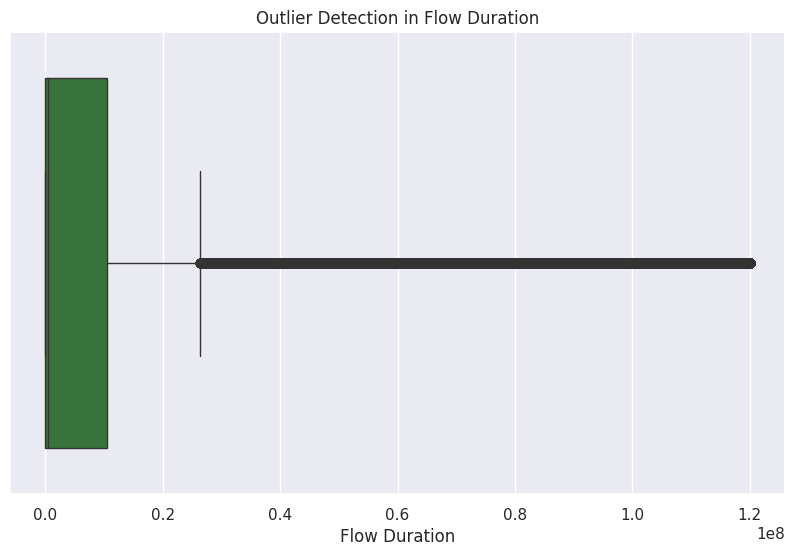

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(x=df_cleaned["Flow Duration"],color="#2E7D32")

plt.title("Outlier Detection in Flow Duration")

plt.show()

Show data and data cleaning & Process for model training

In [ ]:
df_cleaned.head()

,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,6,151054,6,8,1076.0,4575.0,821.0,0.0,179.333333,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,443,6,349,2,0,23.0,0.0,23.0,0.0,11.500000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,443,6,119,2,0,23.0,0.0,23.0,0.0,11.500000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,443,6,37055,1,1,31.0,0.0,31.0,31.0,31.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,443,6,178727,6,7,1313.0,307.0,753.0,0.0,218.833333,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [ ]:

print("Cleaning data...")
df = df_cleaned.replace([np.inf, -np.inf], np.nan)
df.dropna(inplace=True)

#RobustScaler (Numerical Column scaling)
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
num_cols = num_cols.difference(['Label'])
scaler = RobustScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

#Encoding
for col in df.select_dtypes(include=['object']).columns:
    if col != 'Label':
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))
df.head()

Cleaning data...


,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0.0,0.0,-0.034509,1.00,1.75,2.332589,11.864230,2.372372,0.000000,2.725771,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0.0,0.0,-0.048789,0.00,-0.25,-0.017857,-0.080940,-0.024024,0.000000,-0.337679,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,-0.048811,0.00,-0.25,-0.017857,-0.080940,-0.024024,0.000000,-0.337679,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0.0,0.0,-0.045311,-0.25,0.00,0.000000,-0.080940,0.000000,1.347826,0.018253,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,0.0,0.0,-0.031887,1.00,1.50,2.861607,0.720627,2.168168,0.000000,3.446762,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


Binary level setup

In [ ]:
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'Benign' or x == 0 or x == '0' else 1)

X = df.drop(columns=['Label'])
y = df['Label']

Train And test dstribution

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


35 Feature Selection

Selecting top 35 features using Balanced Random Forest...


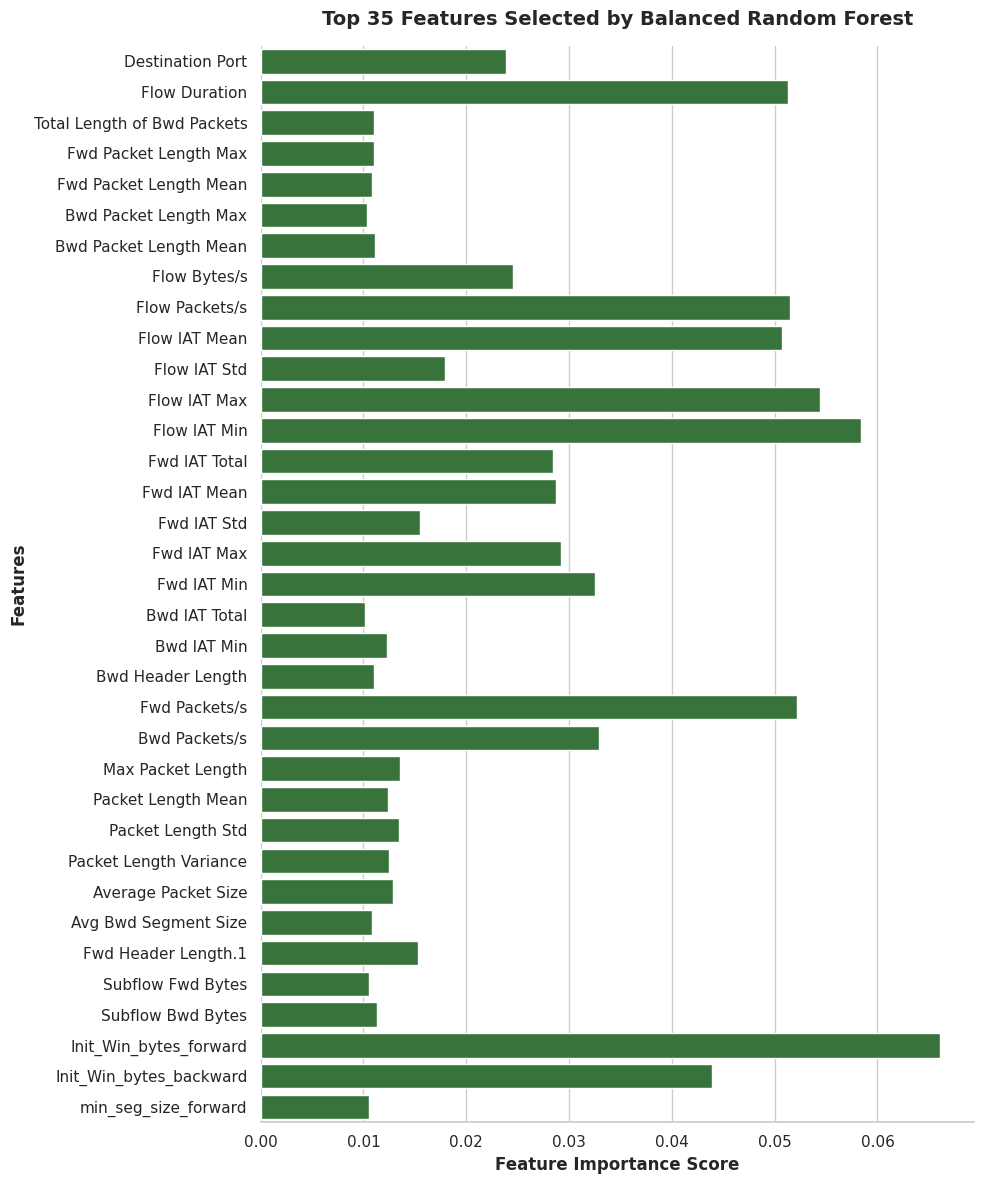

,Init_Win_bytes_forward,Flow IAT Min,Flow IAT Max,Fwd Packets/s,Flow Packets/s,Flow Duration,Flow IAT Mean,Init_Win_bytes_backward,Bwd Packets/s,Fwd IAT Min,...,Bwd Packet Length Mean,Fwd Packet Length Max,Bwd Header Length,Total Length of Bwd Packets,Avg Bwd Segment Size,Fwd Packet Length Mean,min_seg_size_forward,Subflow Fwd Bytes,Bwd Packet Length Max,Bwd IAT Total
157495,-0.022914,417.069454,4.969274,-0.120564,-0.127316,8.434061,26.158403,-0.004184,-0.057101,1131.874681,...,-0.085635,-0.093093,-0.235294,-0.080940,-0.085635,-0.547588,-2.666667,-0.069196,-0.096573,0.000000
284534,-0.007251,-0.016671,-0.030824,39.047797,21.232234,-0.048697,-0.094964,-0.004184,-0.057101,0.035838,...,-0.085635,-0.093093,-0.235294,-0.080940,-0.085635,-0.547588,0.000000,-0.069196,-0.096573,0.000000
84025,-0.022914,0.766400,-0.023334,0.219113,0.243626,-0.041629,-0.051214,-0.004184,0.602104,-0.001766,...,0.323204,0.009009,-0.088235,0.112272,0.323204,0.073012,-1.000000,0.006696,0.133956,0.000000
313134,-0.022914,-0.030517,1.458245,-0.108180,-0.112024,4.018285,0.439901,-0.004184,-0.026789,0.001738,...,0.856354,3.960961,5.882353,11.493473,0.856354,4.920825,0.000000,14.642857,4.109034,159.615391
300691,-0.022914,0.302833,-0.027768,0.692668,0.760110,-0.045814,-0.077113,-0.004184,1.518784,-0.001766,...,0.234807,0.033033,0.000000,0.070496,0.234807,0.219035,0.000000,0.024554,0.084112,0.000000


In [ ]:
print("Selecting top 35 features using Balanced Random Forest...")
selector = RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=42, n_jobs=-1)
selector.fit(X_train, y_train)
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': selector.feature_importances_})
top_features = importance_df.sort_values(by='Importance', ascending=False).head(35)['Feature'].tolist()
#show features
plt.figure(figsize=(10, 12))
sns.set_theme(style="whitegrid", font="DejaVu Sans")

# Horizontal Barplot
sns.barplot(
    x='Importance',
    y='Feature',
    data= importance_df[importance_df['Feature'].isin(top_features)],
    color="#2E7D32"
)

# tittle level
plt.title("Top 35 Features Selected by Balanced Random Forest", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Feature Importance Score", fontsize=12, fontweight="semibold")
plt.ylabel("Features", fontsize=12, fontweight="semibold")

# border clean
sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.show()


X_train_sel = X_train[top_features].copy()
X_test_sel = X_test[top_features].copy()

# Garbage Collection
del df, X, X_train, X_test
gc.collect()

X_train_sel.head()

Satking Classifier Config

In [ ]:
print("Configuring Stacking Classifier...")
estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(n_estimators=150, max_depth=7, scale_pos_weight=1.5, eval_metric='logloss', random_state=42, n_jobs=-1)),
    ('et', ExtraTreesClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1))
]

#meta model
meta_clf = LGBMClassifier(n_estimators=150, learning_rate=0.03, max_depth=8, random_state=42, n_jobs=-1)

stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_clf,
    cv=3,
    stack_method='predict_proba',
    passthrough=True,
    n_jobs=-1
)








Configuring Stacking Classifier...


Model Training  and Evaluation

In [ ]:

print("Training Stacking Classifier ")
stacking_clf.fit(X_train_sel, y_train)

#Prediction
y_pred = stacking_clf.predict(X_test_sel)

#reuslt print
print(f"\n  Stacking Accuracy: {accuracy_score(y_test, y_pred):.5f}")
print(classification_report(y_test, y_pred, digits=5))





Training Stacking Classifier 
[LightGBM] [Info] Number of positive: 244259, number of negative: 30164
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.046278 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9455
[LightGBM] [Info] Number of data points in the train set: 274423, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890082 -> initscore=2.091580
[LightGBM] [Info] Start training from score 2.091580


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



  Stacking Accuracy: 0.92320
              precision    recall  f1-score   support

           0    0.85185   0.36474   0.51078     12927
           1    0.92673   0.99217   0.95833    104684

    accuracy                        0.92320    117611
   macro avg    0.88929   0.67845   0.73456    117611
weighted avg    0.91850   0.92320   0.90914    117611



In [ ]:
X_train_sel.head()

,Init_Win_bytes_forward,Flow IAT Min,Flow IAT Max,Fwd Packets/s,Flow Packets/s,Flow Duration,Flow IAT Mean,Init_Win_bytes_backward,Bwd Packets/s,Fwd IAT Min,...,Bwd Packet Length Mean,Fwd Packet Length Max,Bwd Header Length,Total Length of Bwd Packets,Avg Bwd Segment Size,Fwd Packet Length Mean,min_seg_size_forward,Subflow Fwd Bytes,Bwd Packet Length Max,Bwd IAT Total
157495,-0.022914,417.069454,4.969274,-0.120564,-0.127316,8.434061,26.158403,-0.004184,-0.057101,1131.874681,...,-0.085635,-0.093093,-0.235294,-0.080940,-0.085635,-0.547588,-2.666667,-0.069196,-0.096573,0.000000
284534,-0.007251,-0.016671,-0.030824,39.047797,21.232234,-0.048697,-0.094964,-0.004184,-0.057101,0.035838,...,-0.085635,-0.093093,-0.235294,-0.080940,-0.085635,-0.547588,0.000000,-0.069196,-0.096573,0.000000
84025,-0.022914,0.766400,-0.023334,0.219113,0.243626,-0.041629,-0.051214,-0.004184,0.602104,-0.001766,...,0.323204,0.009009,-0.088235,0.112272,0.323204,0.073012,-1.000000,0.006696,0.133956,0.000000
313134,-0.022914,-0.030517,1.458245,-0.108180,-0.112024,4.018285,0.439901,-0.004184,-0.026789,0.001738,...,0.856354,3.960961,5.882353,11.493473,0.856354,4.920825,0.000000,14.642857,4.109034,159.615391
300691,-0.022914,0.302833,-0.027768,0.692668,0.760110,-0.045814,-0.077113,-0.004184,1.518784,-0.001766,...,0.234807,0.033033,0.000000,0.070496,0.234807,0.219035,0.000000,0.024554,0.084112,0.000000


 Confusion Matrix

Generating Final Confusion Matrix...


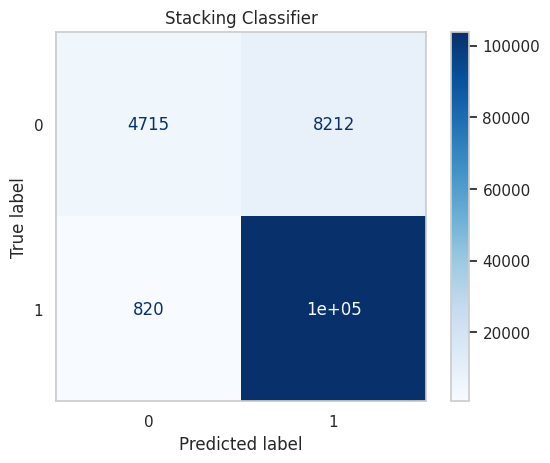

In [ ]:
print("Generating Final Confusion Matrix...")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Stacking Classifier")
plt.grid(False)
plt.show()